## **KLASIFIKASI PENYAKIT KULIT (ECZEMA, RINGWORM, HERPES ZOSTER, NORMAL) - MOBILENETV3 LARGE**

### **IMPORT LIBRARY**

In [ ]:
import os
import time
import copy
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset, Subset, ConcatDataset

from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import files

### **CLONE DATASET DARI GITHUB**

In [ ]:
!git clone https://github.com/Evameivina/skindisease

Cloning into 'skindisease'...
remote: Enumerating objects: 31223, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 31223 (delta 112), reused 3 (delta 3), pack-reused 31040 (from 2)
Receiving objects: 100% (31223/31223), 739.14 MiB | 19.54 MiB/s, done.
Resolving deltas: 100% (272/272), done.
Updating files: 100% (30320/30320), done.


### **DATA UNDERSTANDING**

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"

classes_dir = sorted([c for c in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, c))])

df_info = pd.DataFrame({
    "Class": classes_dir,
    "Total Images": [len(os.listdir(os.path.join(data_dir, c))) for c in classes_dir]
})

classes = df_info['Class'].values

print(f"Jumlah Kelas : {len(df_info)}")
print(f"Total Gambar : {df_info['Total Images'].sum()}\n")

display(df_info)

Jumlah Kelas : 4
Total Gambar : 30260



,Class,Total Images
0,ECZEMA,6715
1,HERPES ZOSTER,8082
2,NORMAL,7334
3,RINGWORM,8129


### **EXPLORATORY DATA ANALYSIS**

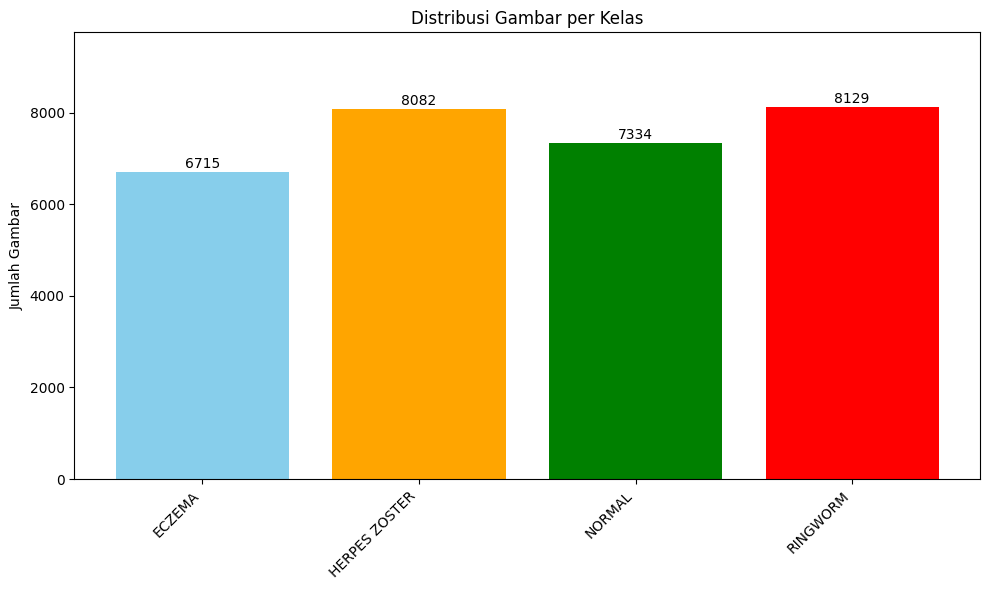

In [ ]:
classes = df_info['Class'].values
counts = df_info['Total Images'].values

plt.figure(figsize=(10,6))

bars = plt.bar(classes, counts, color=['skyblue','orange','green','red'])

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=10)

plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Gambar per Kelas')

plt.ylim(0, max(counts) * 1.2)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

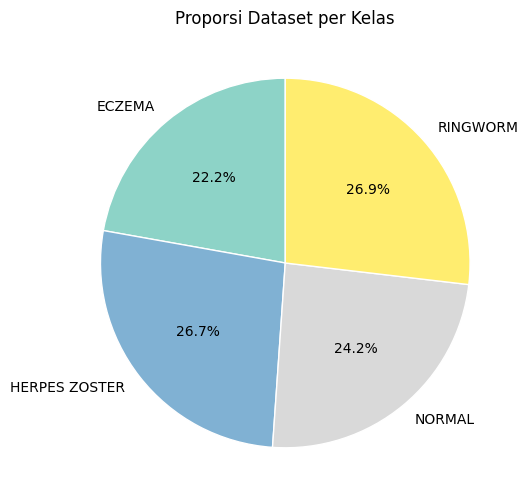

In [ ]:
class_counts = df_info.set_index('Class')['Total Images']

plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(class_counts))),
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title("Proporsi Dataset per Kelas")
plt.show()

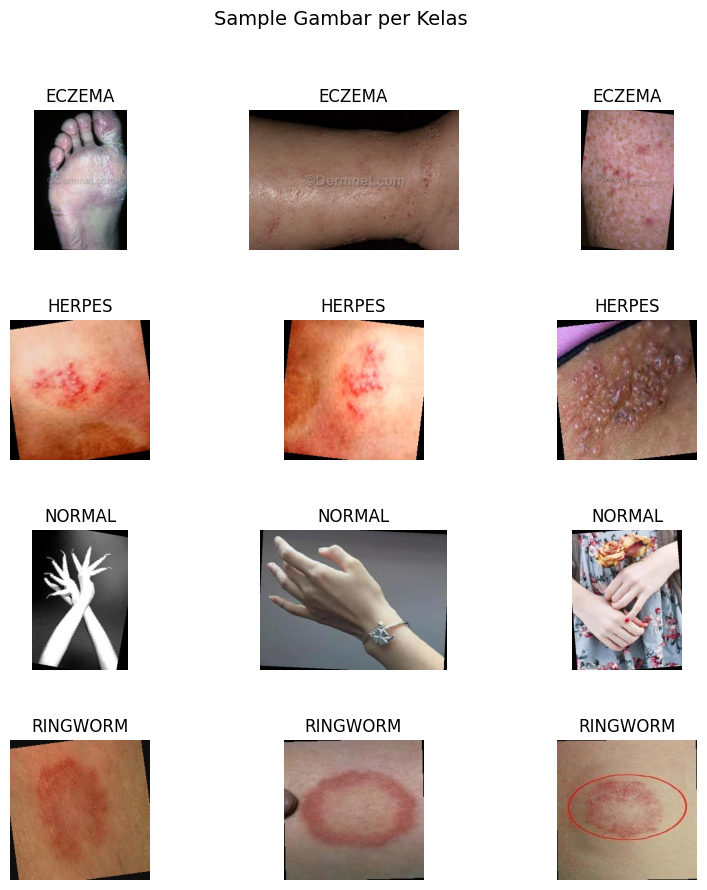

In [ ]:
df_images = pd.DataFrame([
    {
        'filepath': os.path.join(data_dir, c, img),
        'Class': c
    }
    for c in classes_dir
    for img in os.listdir(os.path.join(data_dir, c))
])

plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    class_df = df_images[df_images['Class'] == cls]

    if not class_df.empty:
        samples = class_df.sample(min(3, len(class_df)), random_state=42)

        for j, (_, row) in enumerate(samples.iterrows()):
            plt.subplot(len(classes), 3, i*3 + j + 1)

            img = Image.open(row['filepath']).convert('RGB')
            plt.imshow(img)

            plt.title(cls.split()[0])
            plt.axis('off')

plt.suptitle("Sample Gambar per Kelas", fontsize=14)
plt.subplots_adjust(hspace=0.5)
plt.show()

### **DATA PREPROCESSING & DATA SPLITTING**



In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

In [ ]:
data_dir = "skindisease/Dataset_Klasifikasi"
full_dataset = datasets.ImageFolder(root=data_dir)
all_paths = [p for p, _ in full_dataset.samples]
all_labels = [l for _, l in full_dataset.samples]

In [ ]:
valid_paths, valid_labels = [], []

for p, l in zip(all_paths, all_labels):
    if cv2.imread(p) is not None:
        valid_paths.append(p)
        valid_labels.append(l)

all_paths, all_labels = valid_paths, valid_labels
print("After removing broken images:", len(all_paths))

After removing broken images: 30260


In [ ]:
def hash_image(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

seen = set()
unique_paths, unique_labels = [], []

for p, l in zip(all_paths, all_labels):
    h = hash_image(p)
    if h and h not in seen:
        seen.add(h)
        unique_paths.append(p)
        unique_labels.append(l)

all_paths, all_labels = unique_paths, unique_labels
print("After removing duplicates:", len(all_paths))

After removing duplicates: 30151


In [ ]:
# 10% test
trainval_paths, test_paths, trainval_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.1,
    stratify=all_labels,
    random_state=SEED
)

# 70% train, 20% val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths, trainval_labels,
    test_size=0.2222,
    stratify=trainval_labels,
    random_state=SEED
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 21105
Val: 6030
Test: 3016


In [ ]:
# CHECK DATA LEAKAGE
def get_hash_set(paths):
    hashes = set()
    for p in paths:
        h = hash_image(p)
        if h:
            hashes.add(h)
    return hashes

train_hash = get_hash_set(train_paths)
val_hash   = get_hash_set(val_paths)
test_hash  = get_hash_set(test_paths)

# Cek overlap
train_val_overlap  = train_hash.intersection(val_hash)
train_test_overlap = train_hash.intersection(test_hash)
val_test_overlap   = val_hash.intersection(test_hash)

print("DATA LEAKAGE CHECK")
print(f"Train-Val Overlap  : {len(train_val_overlap)}")
print(f"Train-Test Overlap : {len(train_test_overlap)}")
print(f"Val-Test Overlap   : {len(val_test_overlap)}")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("Tidak ada data leakage")
else:
    print("Ada data yang overlap!")

DATA LEAKAGE CHECK
Train-Val Overlap  : 0
Train-Test Overlap : 0
Val-Test Overlap   : 0
Tidak ada data leakage


### **DATA PREPARATION**

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.RandomAutocontrast(p=0.4),
    transforms.RandomPerspective(0.4, p=0.5),
    transforms.RandomAdjustSharpness(2, p=0.4),
    transforms.GaussianBlur(3, sigma=(0.1, 2.5)),
    transforms.RandomGrayscale(0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert("RGB")
        except:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [ ]:
train_dataset = SkinDataset(train_paths, train_labels, train_transform)
val_dataset   = SkinDataset(val_paths, val_labels, val_test_transform)
test_dataset  = SkinDataset(test_paths, test_labels, val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

### **MODEL 1 - MOBILENETV3 LARGE - STAGE 1 & 2 & CV**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = full_dataset.classes
NUM_CLASSES = len(classes)

# Stage 1
EPOCHS_S1 = 10
LR_S1 = 1e-5
PATIENCE_S1 = 3

# Stage 2
EPOCHS_S2 = 10
LR_S2 = 1e-6
WEIGHT_DECAY_S2 = 1e-4
PATIENCE_S2 = 3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, patience):

    best_acc = 0
    best_wts = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    no_improve = 0

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        train_loss, correct, total = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                out = model(x)
                loss = criterion(out, y)

                val_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {(time.time() - start_time):.2f}s")

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping")
                break

    model.load_state_dict(best_wts)
    return model, history, best_acc

In [ ]:
mobilenet_v3 = models.mobilenet_v3_large(weights='IMAGENET1K_V2')

in_features = mobilenet_v3.classifier[0].in_features

mobilenet_v3.classifier = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.Hardswish(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

mobilenet_v3 = mobilenet_v3.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 181MB/s]


### **STAGE 1 CLASSIFIER**

In [ ]:
print(">>> STAGE 1: WARM-UP CLASSIFIER <<<")

for p in mobilenet_v3.features.parameters():
    p.requires_grad = False

optimizer_s1 = optim.Adam(
    mobilenet_v3.classifier.parameters(),
    lr=LR_S1
)

scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s1,
    mode='min',
    factor=0.5,
    patience=2
)

mobilenet_v3, history1, acc1 = train_model(
    mobilenet_v3,
    train_loader,
    val_loader,
    criterion,
    optimizer_s1,
    scheduler_s1,
    EPOCHS_S1,
    PATIENCE_S1
)

>>> STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/10 | Train Loss: 1.2066 Acc: 0.6556 | Val Loss: 1.0107 Acc: 0.8421 | Time: 243.77s
Epoch 2/10 | Train Loss: 0.9276 Acc: 0.8227 | Val Loss: 0.7945 Acc: 0.8650 | Time: 240.95s
Epoch 3/10 | Train Loss: 0.7711 Acc: 0.8486 | Val Loss: 0.6915 Acc: 0.8804 | Time: 245.60s
Epoch 4/10 | Train Loss: 0.6900 Acc: 0.8709 | Val Loss: 0.6399 Acc: 0.8914 | Time: 240.23s
Epoch 5/10 | Train Loss: 0.6487 Acc: 0.8780 | Val Loss: 0.6067 Acc: 0.9032 | Time: 244.92s
Epoch 6/10 | Train Loss: 0.6162 Acc: 0.8925 | Val Loss: 0.5861 Acc: 0.9139 | Time: 239.71s
Epoch 7/10 | Train Loss: 0.5974 Acc: 0.8978 | Val Loss: 0.5718 Acc: 0.9235 | Time: 244.23s
Epoch 8/10 | Train Loss: 0.5863 Acc: 0.9060 | Val Loss: 0.5572 Acc: 0.9303 | Time: 241.83s
Epoch 9/10 | Train Loss: 0.5766 Acc: 0.9079 | Val Loss: 0.5480 Acc: 0.9358 | Time: 240.57s
Epoch 10/10 | Train Loss: 0.5622 Acc: 0.9180 | Val Loss: 0.5386 Acc: 0.9403 | Time: 243.64s


### **STAGE 2 FINE TUNING**

In [ ]:
print("\n>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")

for param in mobilenet_v3.features[-6:].parameters(): # :4
    param.requires_grad = True

optimizer_s2 = optim.Adam([
    {
        'params': [p for p in mobilenet_v3.features.parameters() if p.requires_grad],
        'lr': LR_S2 / 10
    },
    {
        'params': [p for p in mobilenet_v3.classifier.parameters() if p.requires_grad],
        'lr': LR_S2
    }
], weight_decay=WEIGHT_DECAY_S2)

scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s2,
    mode='min',
    factor=0.2,
    patience=2
)

mobilenet_v3, history2, acc2 = train_model(
    mobilenet_v3,
    train_loader,
    val_loader,
    criterion,
    optimizer_s2,
    scheduler_s2,
    epochs=EPOCHS_S2,
    patience=PATIENCE_S2
)


>>> STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/10 | Train Loss: 0.5546 Acc: 0.9230 | Val Loss: 0.5361 Acc: 0.9418 | Time: 246.49s
Epoch 2/10 | Train Loss: 0.5543 Acc: 0.9211 | Val Loss: 0.5309 Acc: 0.9449 | Time: 246.16s
Epoch 3/10 | Train Loss: 0.5488 Acc: 0.9243 | Val Loss: 0.5260 Acc: 0.9479 | Time: 244.60s
Epoch 4/10 | Train Loss: 0.5444 Acc: 0.9284 | Val Loss: 0.5219 Acc: 0.9499 | Time: 247.55s
Epoch 5/10 | Train Loss: 0.5421 Acc: 0.9282 | Val Loss: 0.5194 Acc: 0.9512 | Time: 246.44s
Epoch 6/10 | Train Loss: 0.5363 Acc: 0.9308 | Val Loss: 0.5180 Acc: 0.9512 | Time: 252.45s
Epoch 7/10 | Train Loss: 0.5325 Acc: 0.9355 | Val Loss: 0.5130 Acc: 0.9536 | Time: 248.47s
Epoch 8/10 | Train Loss: 0.5300 Acc: 0.9343 | Val Loss: 0.5097 Acc: 0.9556 | Time: 249.48s
Epoch 9/10 | Train Loss: 0.5298 Acc: 0.9340 | Val Loss: 0.5082 Acc: 0.9566 | Time: 248.15s
Epoch 10/10 | Train Loss: 0.5270 Acc: 0.9354 | Val Loss: 0.5051 Acc: 0.9575 | Time: 245.16s


In [ ]:
summary(mobilenet_v3, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
       BatchNorm2d-2         [-1, 16, 112, 112]              32
         Hardswish-3         [-1, 16, 112, 112]               0
            Conv2d-4         [-1, 16, 112, 112]             144
       BatchNorm2d-5         [-1, 16, 112, 112]              32
              ReLU-6         [-1, 16, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             256
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 64, 112, 112]           1,024
      BatchNorm2d-11         [-1, 64, 112, 112]             128
             ReLU-12         [-1, 64, 112, 112]               0
           Conv2d-13           [-1, 64, 56, 56]             576
      BatchNorm2d-14           [-1, 64,

### **EVALUATION**

In [ ]:
print("\n" + "="*65)
print("  >>> EVALUATION (TEST SET) <<<")
print("="*65)

mobilenet_v3.eval()
all_preds_test, all_targets_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mobilenet_v3(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_targets_test.extend(labels.cpu().numpy())

correct = sum(p == t for p, t in zip(all_preds_test, all_targets_test))
test_acc = correct / len(all_targets_test) * 100
print(f"Test Accuracy: {test_acc:.2f}%")


  >>> EVALUATION (TEST SET) <<<
Test Accuracy: 96.52%


In [ ]:
# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(all_targets_test, all_preds_test, target_names=classes))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

       ECZEMA       0.96      0.99      0.97       661
HERPES ZOSTER       0.96      0.94      0.95       808
       NORMAL       0.99      1.00      0.99       734
     RINGWORM       0.95      0.94      0.95       813

     accuracy                           0.97      3016
    macro avg       0.97      0.97      0.97      3016
 weighted avg       0.97      0.97      0.97      3016



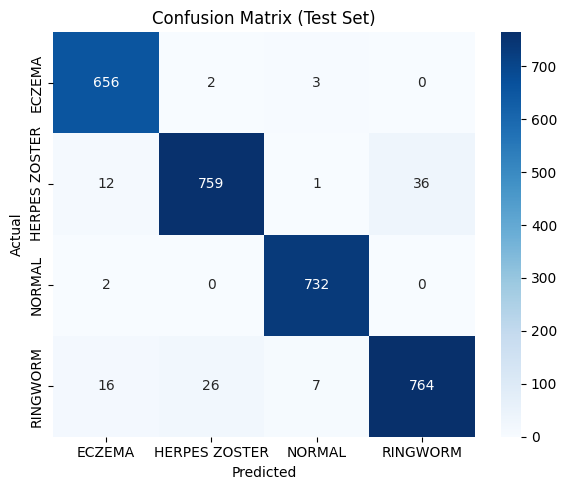

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_targets_test, all_preds_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

In [ ]:
# Akurasi per kelas
print("AKURASI PER KELAS")
class_acc = cm.diagonal() / cm.sum(axis=1)
for cls, acc in zip(classes, class_acc):
    print(f"  {cls:<15} : {acc*100:.2f}%")

AKURASI PER KELAS
  ECZEMA          : 99.24%
  HERPES ZOSTER   : 93.94%
  NORMAL          : 99.73%
  RINGWORM        : 93.97%


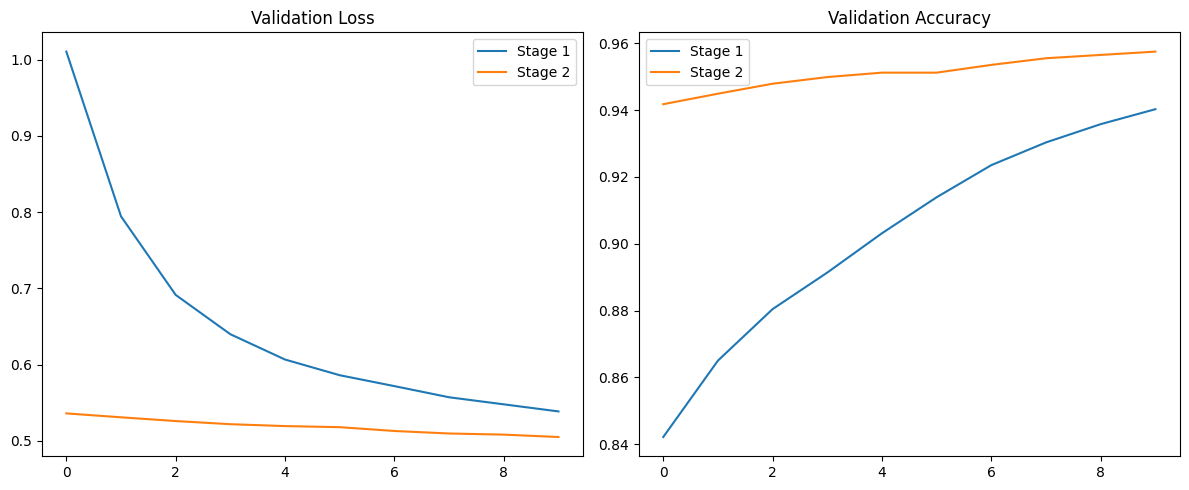

In [ ]:
# Learning Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history1['val_loss'], label='Stage 1')
plt.plot(history2['val_loss'], label='Stage 2')
plt.title("Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1['val_acc'], label='Stage 1')
plt.plot(history2['val_acc'], label='Stage 2')
plt.title("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Model Comparison
print("\n" + "="*65)
print("  >>> MODEL COMPARISON <<<")
print("="*65)
print(f"  Stage 1 Best Val Accuracy : {acc1:.4f}")
print(f"  Stage 2 Best Val Accuracy : {acc2:.4f}")


  >>> MODEL COMPARISON <<<
  Stage 1 Best Val Accuracy : 0.9403
  Stage 2 Best Val Accuracy : 0.9575


### **MODEL SAVING**

In [ ]:
FINAL_MODEL_PATH = "mobilenetv3_skin_disease_finetuned.pth"

torch.save({
    'model_state_dict': mobilenet_v3.state_dict(),
    'classes': classes,
    'stage1_acc': acc1,
    'stage2_acc': acc2
}, FINAL_MODEL_PATH)

print(f"Model fine-tuned disimpan di: {FINAL_MODEL_PATH}")

Model fine-tuned disimpan di: mobilenetv3_skin_disease_finetuned.pth


### **CROSS VALIDATION**

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy, time

k_folds = 3
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=SEED)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(trainval_paths, trainval_labels)):

    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} / {k_folds} <<<")
    print("="*65)

    train_paths_fold  = [trainval_paths[i] for i in train_idx]
    val_paths_fold    = [trainval_paths[i] for i in val_idx]
    train_labels_fold = [trainval_labels[i] for i in train_idx]
    val_labels_fold   = [trainval_labels[i] for i in val_idx]

    fold_train_dataset = SkinDataset(train_paths_fold, train_labels_fold, train_transform)
    fold_val_dataset   = SkinDataset(val_paths_fold, val_labels_fold, val_test_transform)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    print(f"  Train size : {len(fold_train_dataset)} | Val size : {len(fold_val_dataset)}")

    model = models.mobilenet_v3_large(weights='IMAGENET1K_V2')

    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(0.5),
        nn.Linear(256, NUM_CLASSES)
    )

    model = model.to(device)

    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 1: WARM-UP CLASSIFIER <<<")
    print("="*65)

    for p in model.features.parameters():
        p.requires_grad = False

    optimizer_s1 = optim.Adam(model.classifier.parameters(), lr=LR_S1)

    scheduler_s1 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s1,
        mode='min',
        factor=0.5,
        patience=2
    )

    model, _, _ = train_model(
        model,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s1,
        scheduler_s1,
        epochs=5,
        patience=2
    )

    # Stage 2
    print("\n" + "="*65)
    print(f"  >>> FOLD {fold+1} | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<")
    print("="*65)

    for p in model.features[-6:].parameters():
        p.requires_grad = True

    optimizer_s2 = optim.Adam([
        {
            'params': [p for p in model.features.parameters() if p.requires_grad],
            'lr': LR_S2 / 10
        },
        {
            'params': [p for p in model.classifier.parameters() if p.requires_grad],
            'lr': LR_S2
        }
    ], weight_decay=WEIGHT_DECAY_S2)

    scheduler_s2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s2,
        mode='min',
        factor=0.2,
        patience=2
    )

    model, _, fold_acc = train_model(
        model,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer_s2,
        scheduler_s2,
        epochs=5,
        patience=2
    )

    print("\n" + "="*65)
    print(f"  Fold {fold+1} Best Val Accuracy : {fold_acc:.4f}  ({fold_acc*100:.2f}%)")
    print("="*65)

    cv_results.append(fold_acc)


  >>> FOLD 1 / 3 <<<
  Train size : 18090 | Val size : 9045

  >>> FOLD 1 | STAGE 1: WARM-UP CLASSIFIER <<<
Epoch 1/5 | Train Loss: 1.2321 Acc: 0.6437 | Val Loss: 1.0595 Acc: 0.8274 | Time: 220.19s
Epoch 2/5 | Train Loss: 0.9800 Acc: 0.8099 | Val Loss: 0.8452 Acc: 0.8656 | Time: 223.38s
Epoch 3/5 | Train Loss: 0.8151 Acc: 0.8465 | Val Loss: 0.7270 Acc: 0.8799 | Time: 221.20s
Epoch 4/5 | Train Loss: 0.7234 Acc: 0.8622 | Val Loss: 0.6643 Acc: 0.8908 | Time: 223.23s
Epoch 5/5 | Train Loss: 0.6720 Acc: 0.8738 | Val Loss: 0.6296 Acc: 0.8992 | Time: 224.59s

  >>> FOLD 1 | STAGE 2: FINE-TUNING (Unfreeze Last Blocks) <<<
Epoch 1/5 | Train Loss: 0.6463 Acc: 0.8822 | Val Loss: 0.6193 Acc: 0.9038 | Time: 231.86s
Epoch 2/5 | Train Loss: 0.6392 Acc: 0.8828 | Val Loss: 0.6085 Acc: 0.9098 | Time: 228.11s
Epoch 3/5 | Train Loss: 0.6305 Acc: 0.8855 | Val Loss: 0.6044 Acc: 0.9109 | Time: 230.27s
Epoch 4/5 | Train Loss: 0.6202 Acc: 0.8904 | Val Loss: 0.5941 Acc: 0.9180 | Time: 232.33s
Epoch 5/5 | Train

In [ ]:
print("\n" + "="*65)
print("  >>> CROSS-VALIDATION SUMMARY <<<")
print("="*65)
for i, acc in enumerate(cv_results):
    print(f"  Fold {i+1} Val Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"\n  Mean  : {np.mean(cv_results):.4f}  ({np.mean(cv_results)*100:.2f}%)")
print(f"  Std   : {np.std(cv_results):.4f}")


  >>> CROSS-VALIDATION SUMMARY <<<
  Fold 1 Val Accuracy : 0.9200  (92.00%)
  Fold 2 Val Accuracy : 0.9141  (91.41%)
  Fold 3 Val Accuracy : 0.9219  (92.19%)

  Mean  : 0.9187  (91.87%)
  Std   : 0.0033


### **INFERENCE - GAMBAR DATASET (TEST)**

Saving 80_VI-shingles (11).jpg to 80_VI-shingles (11).jpg


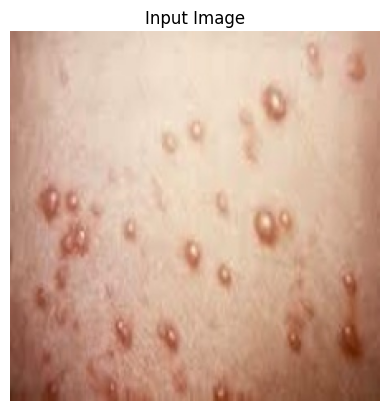

Prediksi: HERPES ZOSTER
Confidence: 0.8452391624450684


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving 70_FU-ringworm (8).jpeg to 70_FU-ringworm (8).jpeg


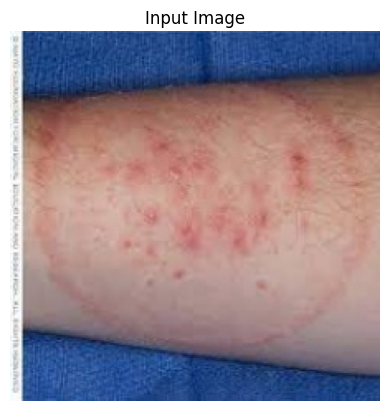

Prediksi: RINGWORM
Confidence: 0.5172407627105713


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()jjjn

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving eczema-fingertips-41.jpg to eczema-fingertips-41.jpg


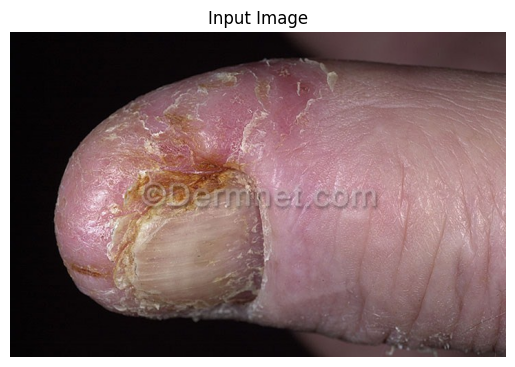

Prediksi: ECZEMA
Confidence: 0.9333096742630005


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving aug_3019_0090.jpg to aug_3019_0090.jpg


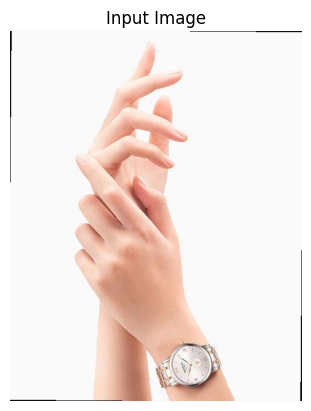

Prediksi: NORMAL
Confidence: 0.9828747510910034


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

### **INFERENCE - GAMBAR DATASET EKSTERNAL (GOOGLE)**

Saving eczema_google13.jpg to eczema_google13.jpg


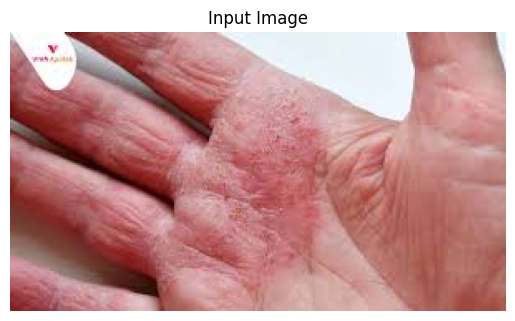

Prediksi: ECZEMA
Confidence: 0.5536437034606934


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving FU-ringworm_google1.jpg to FU-ringworm_google1.jpg


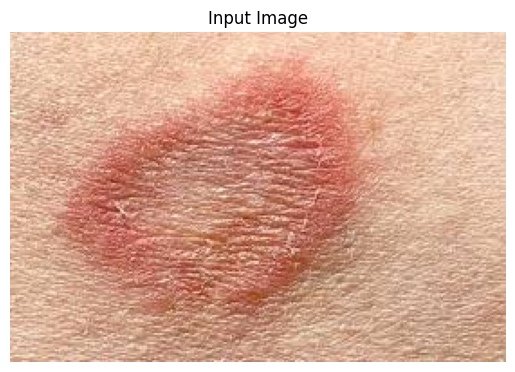

Prediksi: RINGWORM
Confidence: 0.49396827816963196


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving google7.jpg to google7.jpg


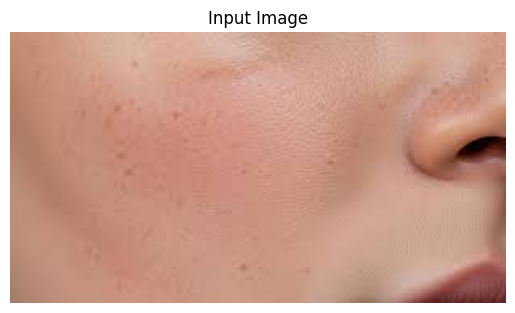

Prediksi: NORMAL
Confidence: 0.3832019567489624


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())

Saving VI_shingles_google15.jpg to VI_shingles_google15.jpg


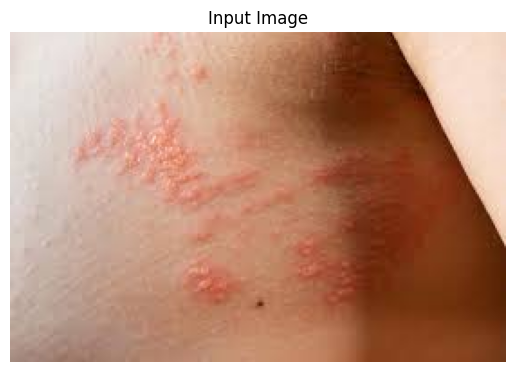

Prediksi: HERPES ZOSTER
Confidence: 0.6408650279045105


In [ ]:
uploaded = files.upload()

mobilenet_v3.eval()

for img_name in uploaded.keys():
    img = Image.open(img_name).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    img_tensor = val_test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = mobilenet_v3(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(output, dim=1).item()

    print("Prediksi:", classes[pred])
    print("Confidence:", probs[0][pred].item())